In [32]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import harmonica as hm
import boule as bl
from numpy.linalg import inv
import spherical as sph

In [33]:
TESLA_TO_NANOTESLA = 1e9

ellipsoid = bl.WGS84

coordinates = vd.grid_coordinates(
    region=(-5, 5, -5, 5),
   shape=(40,40),
    extra_coords=ellipsoid.mean_radius,
)

longitude, sph_latitude, radius_obs = tuple(c.ravel() for c in coordinates)

magnetic_moments_obs = (
    np.full((1, 1), 0.0e9),  
    np.full((1, 1), 0.0e9),        
    np.full((1, 1), 1.0e9)       
)

dipoles = vd.scatter_points(
    region=(-3, 3,-3, 3),
    size= 1,
    extra_coords=ellipsoid.mean_radius - 5e4,
    random_state=0
)

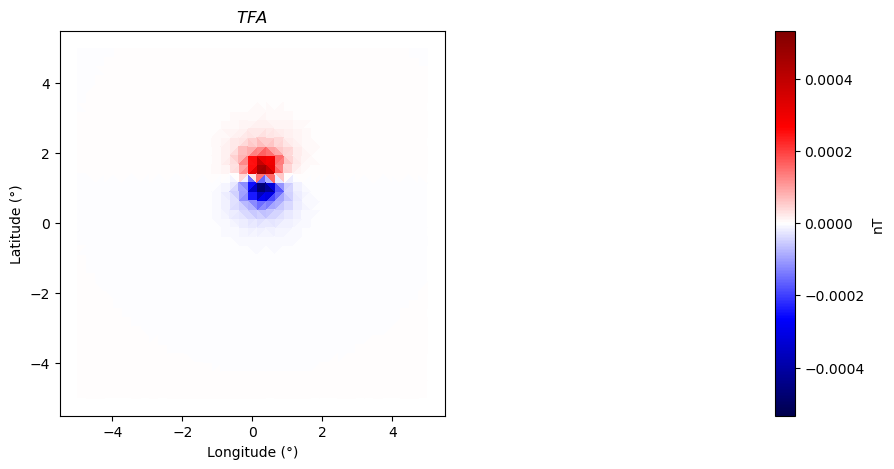

In [34]:
b_field = sph.foward_modeling_spherical(coordinates, dipoles, magnetic_moments_obs)

observed_data = hm.total_field_anomaly(b_field, inclination=0, declination=0)

scale = vd.maxabs(observed_data)

plt.figure(figsize=(15, 5))
plt.tripcolor(longitude, sph_latitude, observed_data, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('$TFA$')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

plt.show()


In [35]:
# def jacobian(coordinates, dipoles, inclination, declination, I_F, D_F):

#     coordinates = tuple(c.ravel() for c in coordinates)
#     dipoles = tuple(d.ravel() for d in dipoles)
    
#     m = dipoles[0].size
#     n = coordinates[0].size
#     A = np.empty((n, m))

#     magnetic_moments = hm.magnetic_angles_to_vec(np.array([1]), np.array([inclination]), np.array([declination]))

#     for j in range(m):
         
#         b_field = sph.foward_modeling_spherical(coordinates, (dipoles[0][j],dipoles[1][j],dipoles[2][j]), magnetic_moments)
#         A[:, j] = hm.total_field_anomaly(b_field,I_F, D_F)

#     return A

In [36]:
def jacobian(coordinates, dipoles, inclination, declination, I_F, D_F):

    coordinates = tuple(c.ravel() for c in coordinates)
    dipoles = tuple(d.ravel() for d in dipoles)
    
    m = dipoles[0].size
    n = coordinates[0].size
    A = np.empty((n, m))

    magnetic_moments = hm.magnetic_angles_to_vec(np.array([1]), np.array([inclination]), np.array([declination]))

    for j in range(m):
        dipole = (dipoles[0][j],dipoles[1][j],dipoles[2][j])
        b_field = sph.foward_modeling_spherical(coordinates, dipole, magnetic_moments)
        A[:, j] = hm.total_field_anomaly(b_field,I_F, D_F)

    return A

In [37]:
estimated_source_coord =  tuple(c.ravel() for c in vd.grid_coordinates(
    region=(-5, 5, -5, 5),
    shape=(40, 40),
    extra_coords=ellipsoid.mean_radius - 2e5
))

A = jacobian(
    coordinates,
    estimated_source_coord,
    0,
    0,
    0,
    0)

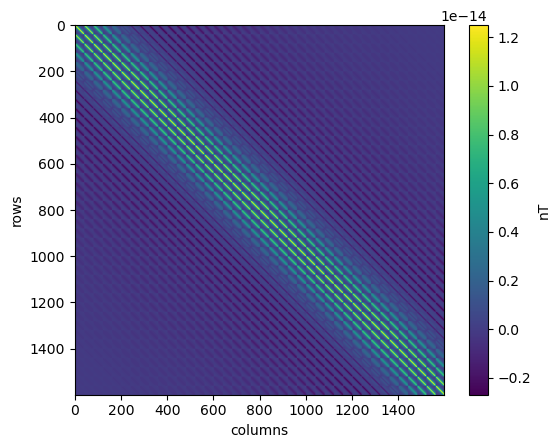

In [38]:
plt.figure()
plt.imshow(A)
plt.colorbar(label="nT")
plt.xlabel("columns")
plt.ylabel("rows")
plt.show()


In [39]:
def calculate_coefficients(observed_data, A, damping):
    
    I = np.identity(A.shape[1]) # needs to = m x m
    # np.shape(A) = A.shape
    
    # The @ operator can be used for conventional matrix multiplication.
    system_matrix = A.T @ A + I * damping 
    
    return coefficients

In [40]:
damping = 1e-2

coefficients = calculate_coefficients(observed_data, A, damping)

In [41]:
grid_coord = vd.grid_coordinates(region= (-7, 7, -7, 7), shape=(100,100), extra_coords=ellipsoid.mean_radius + 100)

grid_0, grid_1, grid_2 = tuple(g.ravel() for g in grid_coord)

grid_data = np.zeros(np.shape(grid_coord[0]))


m = estimated_source_coord[0].size
 

magnetic_moments = hm.magnetic_angles_to_vec(np.array([1]), np.array([0]), np.array([0]))


for j in range(m):

    b_grid = sph.foward_modeling_spherical(grid_coord, (estimated_source_coord[0][j],estimated_source_coord[1][j],estimated_source_coord[2][j]), magnetic_moments)
    grid_data =+ coefficients[j] * hm.total_field_anomaly(b_grid,0, 0)

In [42]:
b_field_obs = sph.foward_modeling_spherical(grid_coord, dipoles, magnetic_moments_obs)
grid_obs = hm.total_field_anomaly(b_field_obs, 0,0)

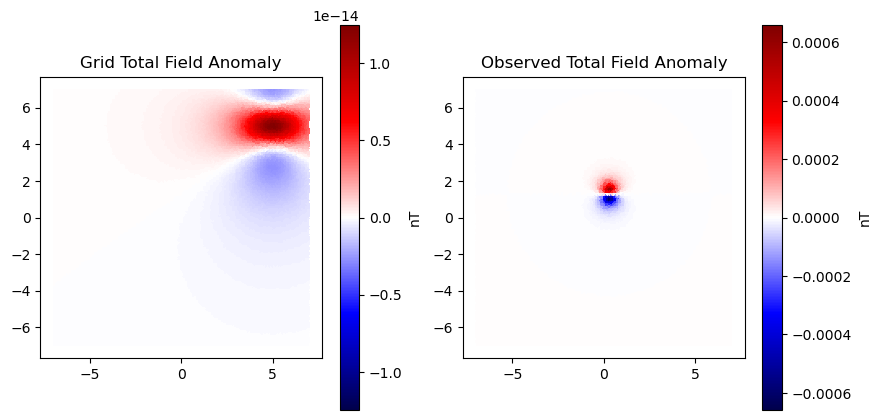

In [43]:
plt.figure(figsize=(10, 5))
scale = vd.maxabs(grid_data)
plt.subplot(1, 2, 1)
plt.tripcolor(grid_0, grid_1, grid_data, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('Grid Total Field Anomaly')
plt.axis("scaled")

plt.subplot(1,2,2)
scale_obs = vd.maxabs(grid_obs)
plt.tripcolor(grid_0, grid_1, grid_obs, cmap="seismic", vmin=-scale_obs, vmax=scale_obs)
plt.colorbar(label='nT')
plt.title('Observed Total Field Anomaly')
plt.axis("scaled")

plt.show()

Text(0.5, 1.0, 'Difference')

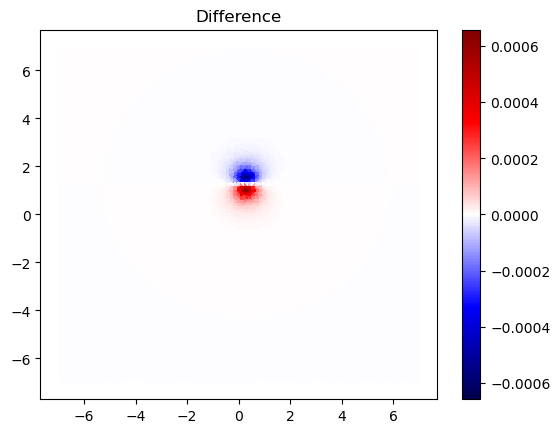

In [44]:
diff = grid_data - grid_obs
scale = vd.maxabs(diff)
plt.tripcolor(grid_0, grid_1, diff,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar()
plt.title('Difference')

In [45]:
mse = np.square(diff).mean() 
rmse = np.sqrt(mse)
rmse

np.float64(2.7467414497990052e-05)